# 载入数据

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] =['SimHei']
plt.rcParams['axes.unicode_minus'] = False

#读取csv文件
file_path=r"D:\DA\project\online_retail_II.csv"
#转义
df=pd.read_csv(file_path, encoding='latin1', parse_dates=['InvoiceDate'])

#查看基本数据信息
print('数据形状:', df.shape)
print('\n前5行数据')
df.head()

数据形状: (1067371, 8)

前5行数据


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# 数据清洗

In [6]:
# 1.查看缺失值
print('查看缺失值')
print(df.isnull().sum())

#2.删除customerID为空的记录
df=df.dropna(subset=['Customer ID'])

#3.删除取消订单
df=df[~df['Invoice'].str.startswith('C',na=False)]

#4.删除数量<=0或 价格 <=0的记录
df= df[(df['Quantity']>0)&(df['Price']>0)]

#5. 新增总金额列
df['TotalAmount']=df['Quantity']*df['Price']

print(f'清洗后数据量:{len(df)}')
print(f'唯一客户数:{df['Customer ID'].nunique()}')

查看缺失值
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64
清洗后数据量:805549
唯一客户数:5878


# 计算基础指标

In [7]:
total_revenue= df['TotalAmount'].sum()
total_orders= df['Invoice'].nunique()
total_customers= df['Customer ID'].nunique()
avg_order_value = total_revenue / total_orders
avg_revenue_per_customer = total_revenue / total_customers

print('===整体===')
print(f'总销售额:{total_revenue:,.2f}')
print(f'总订单数:{total_orders:,}')
print(f'总客户数:{total_customers:,}')
print(f'客单价:{avg_order_value:,.2f}')
print(f'人均消费:{avg_revenue_per_customer:,.2f}')


===整体===
总销售额:17,743,429.18
总订单数:36,969
总客户数:5,878
客单价:479.95
人均消费:3,018.62


# RFM用户分层

In [12]:
#计算RFM
rfm=df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (pd.Timestamp.now() - x.max()).days,  # R: 最近一次购买距今天数
    'Invoice': 'nunique',                                           # F: 购买次数
    'TotalAmount': 'sum'                                            # M: 总金额
}).rename(columns={'InvoiceDate': 'R', 'Invoice': 'F', 'TotalAmount': 'M'})

#打分（1~5分，数值越高代表表现越好）
#R越小越好，则分位数分桶时反序
rfm['R_score'] = pd.qcut(rfm['R'],5,labels=[5,4,3,2,1])
f_bins = pd.qcut(rfm['F'].rank(method='min'), 5, duplicates='drop')
m_bins = pd.qcut(rfm['M'].rank(method='min'), 5, duplicates='drop')

# 将分位数映射到1-5的分数
f_labels = {cat: i+1 for i, cat in enumerate(f_bins.cat.categories)}
m_labels = {cat: i+1 for i, cat in enumerate(m_bins.cat.categories)}

rfm['F_score'] = f_bins.map(f_labels)
rfm['M_score'] = m_bins.map(m_labels)


#用户分层
conditions = [
    (rfm['R_score'] >= 4) & (rfm['F_score'] >= 4) & (rfm['M_score'] >= 4),
    (rfm['R_score'] >= 3) & (rfm['F_score'] >= 3) & (rfm['M_score'] >= 3),
    (rfm['R_score'] <= 2) & (rfm['F_score'] <= 2) & (rfm['M_score'] <= 2)
]
choices = ['高价值用户', '潜力用户', '流失用户']

rfm['segment'] = np.select(conditions, choices, default='一般用户')

#查看各分层用户占比与销售额贡献
segment_sum = rfm.groupby('segment').agg(
    用户数=('segment','count'),
    总消费金额=('M','sum')
).sort_values('总消费金额',ascending=False)

segment_sum['用户占比(%)']=(segment_sum['用户数']/segment_sum['用户数'].sum())*100
segment_sum['销售额占比(%)'] = (segment_sum['总消费金额'] / segment_sum['总消费金额'].sum()) * 100

print('===用户分层结果===')
print(segment_sum)

===用户分层结果===
          用户数         总消费金额    用户占比(%)   销售额占比(%)
segment                                          
一般用户     3377  1.224491e+07  57.451514  69.010951
高价值用户     547  3.914664e+06   9.305886  22.062614
潜力用户      489  1.121358e+06   8.319156   6.319847
流失用户     1465  4.624980e+05  24.923443   2.606588


# 复购率分析

In [14]:
# 每个用户的订单数
user_order_counts=df.groupby('Customer ID')['Invoice'].nunique().reset_index(name='order_count')

#整体复购率（购买>=2次）
repeat_users = user_order_counts[user_order_counts['order_count']>=2].shape[0]
total_users = user_order_counts.shape[0]
repeat_rate = repeat_users / total_users *100
print(f'整体复购率:{repeat_rate:.2f}%')

#月度复购率（当月购买用户中，曾经购买的比例）
df['year_month'] = df['InvoiceDate'].dt.to_period('M')
#获取每个用户首次购买月份
first_purchase = df.groupby('Customer ID')['year_month'].min().reset_index(name='first_month')
#按月份统计用户购买情况
monthly_users = df.groupby(['year_month', 'Customer ID']).size().reset_index(name='count')
monthly_users = monthly_users.merge(first_purchase, on='Customer ID',how='left')
monthly_users['repeat'] = monthly_users['year_month'] > monthly_users['first_month']

monthly_repeat = monthly_users.groupby('year_month').agg(
    total_buyers=('Customer ID','nunique'),
    repeat_buyers = ('repeat', 'sum')
).reset_index()
monthly_repeat['repeat_rate'] = monthly_repeat['repeat_buyers'] / monthly_repeat['total_buyers']*100

print('\n===月度复购率===')
print(monthly_repeat.head())

整体复购率:72.39%

===月度复购率===
  year_month  total_buyers  repeat_buyers  repeat_rate
0    2009-12           955              0     0.000000
1    2010-01           720            337    46.805556
2    2010-02           772            398    51.554404
3    2010-03          1057            614    58.088931
4    2010-04           942            648    68.789809


# 漏斗分析（首次购买→二次购买）

In [15]:
#每个用户的首次购买日次
first_buy = df.groupby('Customer ID')['InvoiceDate'].min().reset_index(name='first_date')
#二次购买日期
second_buy = df[df['InvoiceDate']>df.groupby('Customer ID')['InvoiceDate'].transform('min')]\
.groupby('Customer ID')['InvoiceDate'].min().reset_index(name='second_date')

first_count=first_buy.shape[0]
second_count=second_buy.shape[0]
conversion_rate=second_count/first_count *100

print('===首次→二次购买漏斗 ===')
print(f'首次购买用户数:{first_count}')
print(f'二次购买用户数:{second_count}')
print(f'转化率:{conversion_rate:.2f}%')

===首次→二次购买漏斗 ===
首次购买用户数:5878
二次购买用户数:4256
转化率:72.41%


# 时间趋势与地域分析

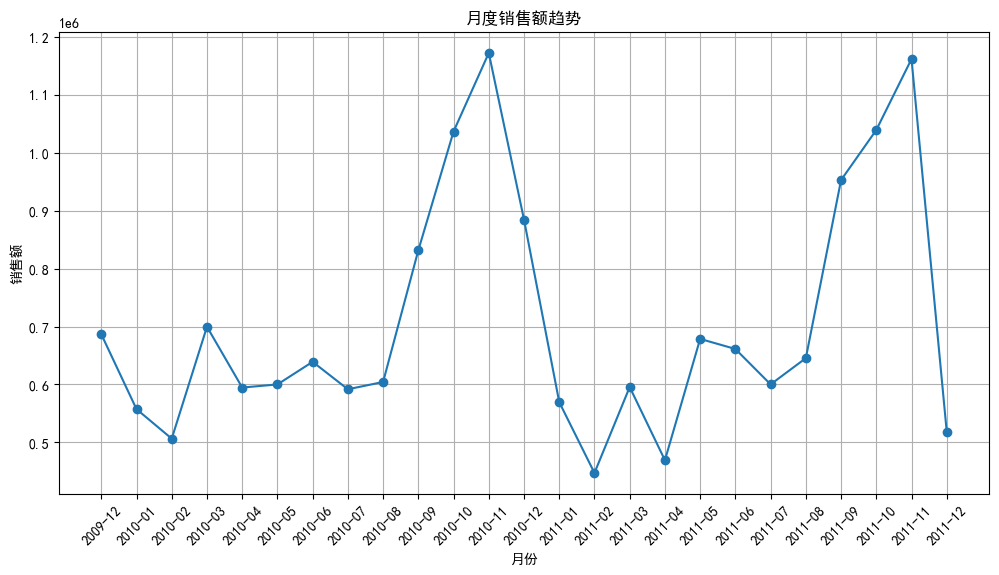

C:\Users\huang\AppData\Local\Temp\ipykernel_14108\209474202.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_sales.values, y=country_sales.index, palette='viridis')


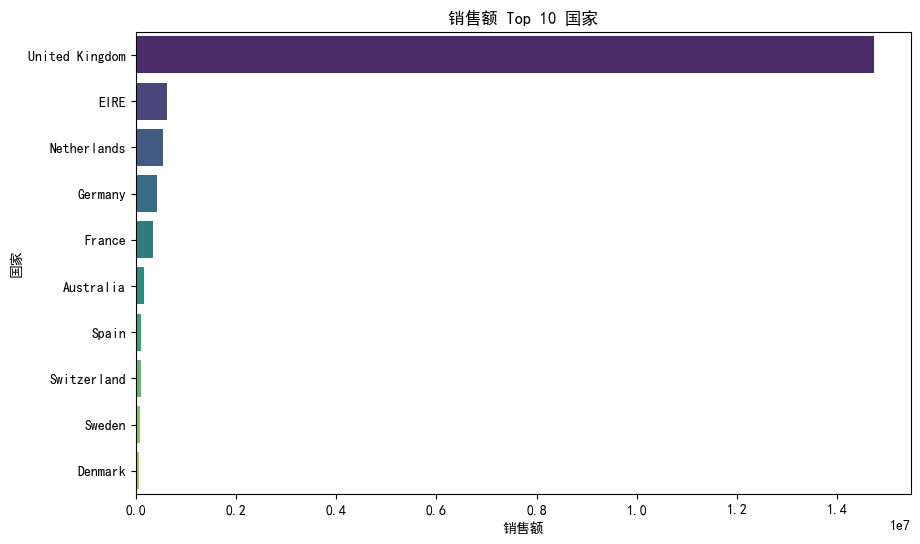

In [18]:
#月度销售额趋势
monthly_sales = df.groupby(df['InvoiceDate'].dt.to_period('M'))['TotalAmount'].sum().reset_index()
monthly_sales.columns=['month','revenue']

plt.figure(figsize=(12,6))
plt.plot(monthly_sales['month'].astype(str), monthly_sales['revenue'], marker='o')
plt.xticks(rotation=45)
plt.title('月度销售额趋势')
plt.xlabel('月份')
plt.ylabel('销售额')
plt.grid(True)
plt.show()

# 国家销售额 Top 10
country_sales=df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=country_sales.values, y=country_sales.index, palette='viridis')
plt.title('销售额 Top 10 国家')
plt.xlabel('销售额')
plt.ylabel('国家')
plt.show()

# 保存分析结果

In [19]:
# 保存 RFM 分层结果
rfm.to_csv('rfm_result.csv', encoding='utf-8-sig')

# 保存月度复购率
monthly_repeat.to_csv('monthly_repeat_rate.csv', encoding='utf-8-sig', index=False)

# 保存国家销售额
country_sales.to_csv('country_sales_top10.csv', encoding='utf-8-sig')